# 04 — Análise dos Dados e Conclusões

Este notebook utiliza os dados consolidados na camada Gold para investigar as diferenças na expectativa de vida entre os países analisados em 2013 e sua relação com indicadores educacionais, econômicos e de saúde.

As análises buscam responder às perguntas definidas no início do MVP por meio de estatísticas descritivas, comparações entre grupos, correlações e visualizações. O IDH é utilizado apenas de forma complementar, uma vez que a expectativa de vida constitui uma das dimensões empregadas na construção desse índice.

1. Preparação da base analítica

In [0]:
# Importar as bibliotecas utilizadas nas análises e visualizações 
from pyspark.sql import functions as F 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 



# Carregar as estruturas da camada Gold 
fato = spark.table("workspace.gold.fato_saude_desenvolvimento") 
dim_pais = spark.table("workspace.gold.dim_pais") 
dim_tempo = spark.table("workspace.gold.dim_tempo") 

# Reconstruindo a visão analítica contendo os indicadores e as informações dos países 
df_analise = ( fato .join(dim_pais, on="id_pais", how="inner") 
              .join(dim_tempo, on="id_tempo", how="inner") 
              .select( "pais", "ano", "status", "exp_vida", "mortalidade_adulta", "mortalidade_infantil", "mortalidade_hiv", "consumo_alcool", "imc", "pib_dolar", "anos_escolaridade_media", "indice_educacao", "idh" ) ) 

print(f"Base analítica: {df_analise.count()} países") 
display(df_analise.limit(10))

Base analítica: 180 países


pais,ano,status,exp_vida,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,imc,pib_dolar,anos_escolaridade_media,indice_educacao,idh
Afghanistan,2013,Developing,59.9,268.0,66.0,0.1,0.01,18.1,631.744976,10.2,0.4372222222222222,0.484962004929948
Albania,2013,Developing,77.2,84.0,0.0,0.1,4.76,56.5,4414.72314,14.8,0.7627777777777778,0.781171149321141
Algeria,2013,Developing,75.3,112.0,21.0,0.1,0.53,57.2,5471.866766,14.3,0.6933333333333334,0.745817134419061
Angola,2013,Developing,51.1,355.0,69.0,2.3,8.1,22.1,484.616884,10.3,0.4794444444444445,0.547266233129838
Antigua and Barbuda,2013,Developing,76.1,133.0,0.0,0.2,8.58,46.4,12224.86416,13.0,0.6888888888888889,0.767347961741302
Argentina,2013,Developing,76.0,119.0,8.0,0.1,8.28,61.6,12976.63642,17.1,0.8422222222222223,0.824245166877387
Armenia,2013,Developing,74.4,123.0,1.0,0.1,3.79,53.3,3843.591213,13.0,0.75,0.7434815305781
Australia,2013,Developed,82.5,61.0,1.0,0.1,9.87,65.5,67792.3386,20.4,null,0.926368881043257
Austria,2013,Developed,81.1,68.0,0.0,0.1,11.82,56.6,554.71532,15.8,0.8572222222222223,0.896416350346645
Azerbaijan,2013,Developing,72.2,121.0,5.0,0.1,2.14,5.6,7875.756953,12.2,0.7066666666666667,0.740645466085216


Como a base final possui poucos registros, podemos convertê-la para Pandas para facilitar as análises estatísticas e as visualizações.

In [0]:
df = df_analise.toPandas()

2. Perfil geral da expectativa de vida

count    176.000000
mean      71.535227
std        8.323606
min       49.900000
25%       66.000000
50%       73.500000
75%       76.825000
max       87.000000
Name: exp_vida, dtype: float64


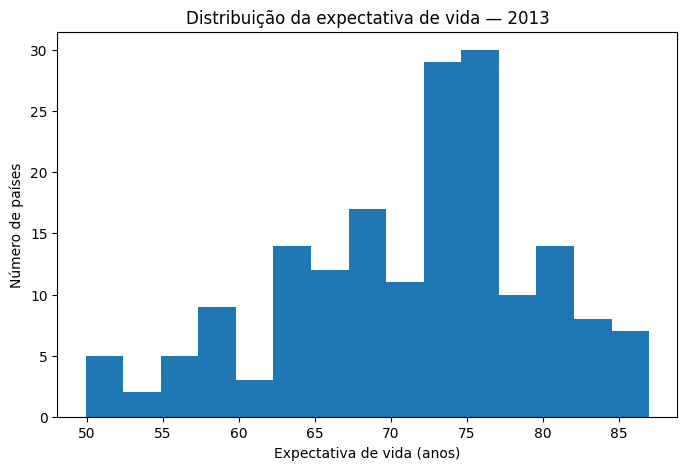

In [0]:
# Calcular estatísticas descritivas da expectativa de vida em 2013
print(df["exp_vida"].describe())

# Visualizar a distribuição da expectativa de vida entre os países
plt.figure(figsize=(8, 5))
plt.hist(df["exp_vida"].dropna(), bins=15)

plt.xlabel("Expectativa de vida (anos)")
plt.ylabel("Número de países")
plt.title("Distribuição da expectativa de vida — 2013")
plt.show()

Em 2013, a expectativa de vida apresentou média de aproximadamente 71,5 anos e mediana de 73,5 anos entre os países com dados disponíveis, variando de 49,9 a 87 anos. A distribuição evidencia heterogeneidade relevante entre os países, justificando a investigação de fatores educacionais, econômicos e de saúde potencialmente associados a essas diferenças.

3. Países desenvolvidos versus países em desenvolvimento

count,mean,median,std
32,80.68,81.35,3.81
144,69.5,71.0,7.67


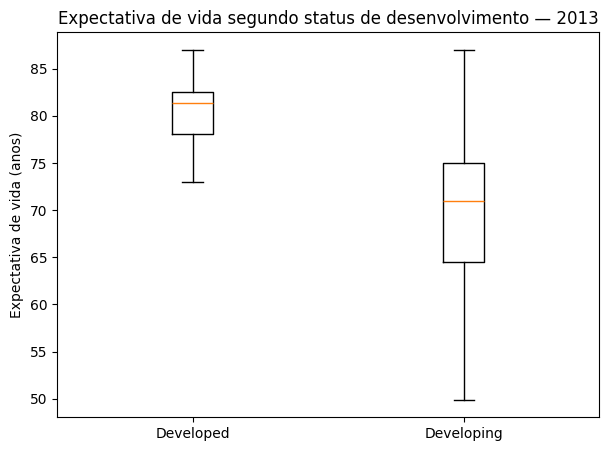

In [0]:
# Comparar a expectativa de vida média segundo o status de desenvolvimento
comparacao_status = (
    df.groupby("status")["exp_vida"]
    .agg(["count", "mean", "median", "std"])
    .round(2))

display(comparacao_status)

# Gráfico da distribuição entre os dois grupos
dados_status = [
    grupo["exp_vida"].dropna()
    for _, grupo in df.groupby("status")]

rotulos = list(df.groupby("status").groups.keys())

plt.figure(figsize=(7, 5))
plt.boxplot(dados_status, tick_labels=rotulos)

plt.ylabel("Expectativa de vida (anos)")
plt.title("Expectativa de vida segundo status de desenvolvimento — 2013")
plt.show()

4. Educação e renda

Correlação escolaridade × expectativa de vida: 0.803


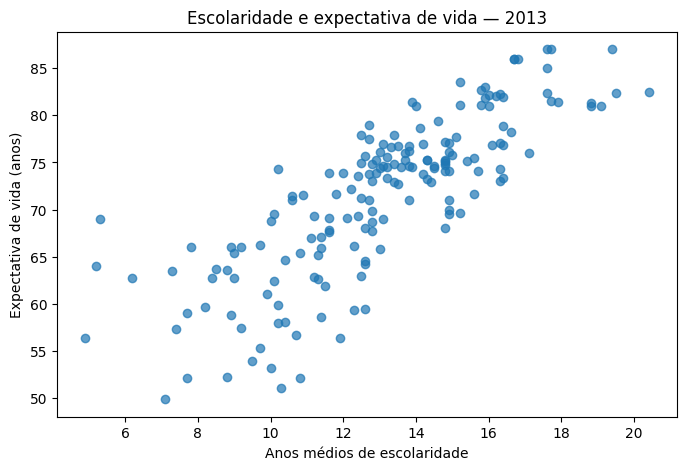

In [0]:
#----------------- Escolaridade e expectativa de vida

# Calcular a correlação entre escolaridade e expectativa de vida
corr_escolaridade = df[["anos_escolaridade_media", "exp_vida"]].corr().iloc[0, 1]

print(f"Correlação escolaridade × expectativa de vida: " f"{corr_escolaridade:.3f}")

# Visualizar a associação entre escolaridade e expectativa de vida
plt.figure(figsize=(8, 5))
plt.scatter(
    df["anos_escolaridade_media"],
    df["exp_vida"],
    alpha=0.7)

plt.xlabel("Anos médios de escolaridade")
plt.ylabel("Expectativa de vida (anos)")
plt.title("Escolaridade e expectativa de vida — 2013")
plt.show()

Foi observada forte associação positiva entre anos médios de escolaridade e expectativa de vida (r = 0,803). Países com maiores níveis médios de escolaridade tenderam a apresentar maior longevidade, constituindo uma das associações mais expressivas identificadas no conjunto de dados.

Correlação log(PIB) × expectativa de vida: 0.593


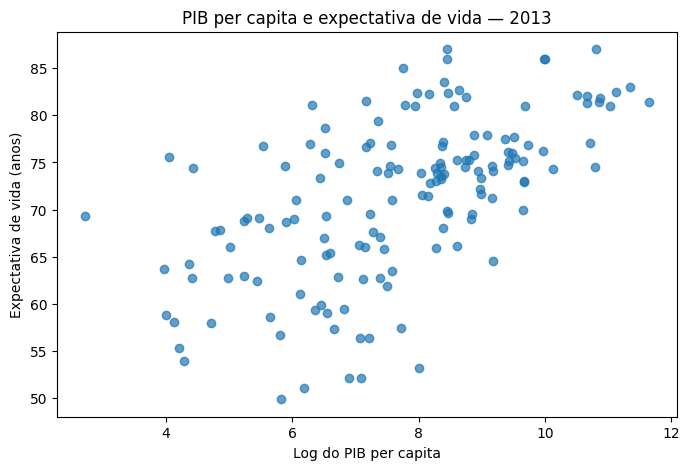

In [0]:
#----------------- PIB per capita e expectativa de vida
# Como o PIB apresenta distribuição fortemente assimétrica entre os países, utiliza-se sua transformação logarítmica para facilitar a comparação

# Criar o logaritmo do PIB para reduzir a assimetria da distribuição
df["log_pib"] = np.log1p(df["pib_dolar"])

corr_pib = df[["log_pib", "exp_vida"]].corr().iloc[0, 1]

print(f"Correlação log(PIB) × expectativa de vida: "f"{corr_pib:.3f}")

# Visualizar a relação entre renda e expectativa de vida
plt.figure(figsize=(8, 5))
plt.scatter(
    df["log_pib"],
    df["exp_vida"],
    alpha=0.7)

plt.xlabel("Log do PIB per capita")
plt.ylabel("Expectativa de vida (anos)")
plt.title("PIB per capita e expectativa de vida — 2013")
plt.show()

O logaritmo do PIB per capita apresentou correlação positiva moderada com a expectativa de vida (r = 0,593). O resultado indica que maior nível econômico tende a estar associado a maior longevidade, embora a relação observada seja menos intensa que aquela encontrada para os indicadores educacionais.

5. Indicadores mais associados à expectativa de vida

In [0]:
# Selecionando os principais indicadores quantitativos analisados no MVP 
variaveis = [ "exp_vida", "mortalidade_adulta", "mortalidade_infantil", "mortalidade_hiv", "consumo_alcool", "imc", "log_pib", "anos_escolaridade_media", "indice_educacao", "idh" ] 

# Calcular a correlação de cada indicador com a expectativa de vida 
correlacoes = (df[variaveis] .corr()["exp_vida"] .drop("exp_vida") .sort_values(key=abs, ascending=False) .round(3) ) 

# Organiza as correlações em uma tabela com o nome dos indicadores
tabela_correlacoes = (
    correlacoes
    .rename("correlacao_com_exp_vida")
    .reset_index()
    .rename(columns={"index": "indicador"})
)

display(tabela_correlacoes)

indicador,correlacao_com_exp_vida
idh,0.893
indice_educacao,0.818
anos_escolaridade_media,0.803
mortalidade_adulta,-0.717
mortalidade_hiv,-0.643
log_pib,0.593
imc,0.494
consumo_alcool,0.483
mortalidade_infantil,-0.231


Os indicadores educacionais apresentaram algumas das associações mais fortes com a expectativa de vida, destacando-se o índice de educação (r = 0,818) e os anos médios de escolaridade (r = 0,803). Entre os indicadores de saúde, mortalidade adulta (r = −0,717) e mortalidade relacionada ao HIV (r = −0,643) apresentaram as associações negativas mais relevantes. O IDH apresentou a maior correlação (r = 0,893), mas esse resultado deve ser interpretado de forma complementar, pois a expectativa de vida integra a própria composição do índice.

6. Países com maior e menor expectativa de vida

In [0]:
# Identificando os países com maiores valores de expectativa de vida
maiores = (
    df[["pais", "status", "exp_vida"]]
    .dropna()
    .sort_values("exp_vida", ascending=False)
    .head(10)
)

display(maiores)

# Identificando os países com menores valores de expectativa de vida
menores = (
    df[["pais", "status", "exp_vida"]]
    .dropna()
    .sort_values("exp_vida")
    .head(10)
)

display(menores)

pais,status,exp_vida
Belgium,Developed,87.0
Finland,Developing,87.0
United Kingdom of Great Britain and Northern Ireland,Developed,87.0
Greece,Developing,86.0
Germany,Developed,86.0
Portugal,Developed,86.0
Slovenia,Developed,85.0
Japan,Developed,83.5
Switzerland,Developed,83.0
Singapore,Developed,82.7


pais,status,exp_vida
Central African Republic,Developing,49.9
Angola,Developing,51.1
Lesotho,Developing,52.1
Chad,Developing,52.2
Côte d'Ivoire,Developing,52.3
Nigeria,Developing,53.2
Sierra Leone,Developing,54.0
Mozambique,Developing,55.3
South Sudan,Developing,56.4
Cameroon,Developing,56.4


A análise dos extremos evidenciou grandes diferenças na expectativa de vida entre os países em 2013, com valores variando de 49,9 a 87 anos. Entre os menores valores observados estavam República Centro-Africana, Angola, Lesoto, Chade e Costa do Marfim. No extremo superior, diversos países apresentaram expectativa de vida acima de 80 anos. Esses resultados reforçam as diferenças internacionais observadas e complementam as associações encontradas com indicadores educacionais, econômicos e de saúde.

## Conclusão

A análise dos dados de 2013 mostrou importantes diferenças na expectativa de vida entre os países avaliados. Os indicadores educacionais apresentaram algumas das associações positivas mais fortes com a longevidade, destacando-se o índice de educação e os anos médios de escolaridade. O PIB per capita também apresentou associação positiva, enquanto mortalidade adulta e mortalidade relacionada ao HIV apresentaram associações negativas relevantes. Os resultados sugerem que diferenças educacionais, econômicas e de saúde estão relacionadas às desigualdades internacionais de expectativa de vida observadas no período analisado. O IDH apresentou forte correlação com a expectativa de vida, mas foi interpretado apenas de forma complementar devido à presença da longevidade em sua própria composição.

## Limitações

O MVP utiliza um recorte transversal referente ao ano de 2013, o que permite identificar associações, mas não estabelecer relações de causalidade ou avaliar mudanças ao longo do tempo. Também foram observados dados ausentes em alguns atributos e problemas de unicidade na base de desenvolvimento humano, tratados durante a construção do pipeline. Além disso, as análises dependem das definições e classificações adotadas pelas fontes originais.

## Autoavaliação

Os principais objetivos definidos para o MVP foram atingidos. Foi possível construir um pipeline em nuvem no Databricks, desde a ingestão e armazenamento dos dados até a criação das camadas Bronze, Silver e Gold, integração das fontes, modelagem dimensional e análise dos indicadores. Entre as principais dificuldades estiveram o tratamento de formatos numéricos, a identificação de duplicidades e a conciliação entre bases distintas. Como trabalhos futuros, o projeto pode ser ampliado para outros anos, permitindo análises temporais, além da inclusão de novas fontes e métodos estatísticos mais avançados.